# Task 1: Article-Type Classification

## 1. Introduction

Article-type classification identifies the kind of fashion item shown in an image, such as a T-shirt, dress, handbag or pair of shoes. This task supports catalogue labelling and product discovery. It is challenging because visually similar categories can overlap in shape and colour, while the training data contain many rare classes.

This notebook investigates image-based prediction of the 124 usable `articleType` categories. It compares a majority baseline, logistic regression using HOG shape descriptors and HSV colour histograms, and a compact convolutional neural network trained from scratch. Accuracy, supported-label macro F1 and calibration are considered together so that common categories do not dominate the assessment. The selected final recipe uses standardized HOG + HSV features, logistic regression with C = 0.1, square-root class weights and training-only brightness views of 0.9, 1.0 and 1.1.

The workflow covers target-specific exploration, baseline comparison, final-model training, validation-based calibration and review thresholds, internal-test evaluation, and figure export. It preserves the original dataset and the grouped split established in Task 0. The test partition has prior development exposure, so its results are internal evaluation rather than independent real-world testing.

**Execution:** Run All trains the baselines and selected final recipe, replacing checkpoints and histories directly in `models/` and exporting report figures to `figures/`.


## 2. Library Imports and Setup

In [ ]:
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, top_k_accuracy_score)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch

from app.server.utils.modeling import SimpleCNN
from scripts.classification import make_loader, train_cnn, predict_cnn, comparison_row
from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame

seed_everything(SEED)
torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
DEVICE


(ROOT / 'models').mkdir(exist_ok=True)
torch.set_num_threads(4)

## 3. Load the Frozen Data

In [ ]:
TARGET = 'articleType'
train_df = task_frame(TARGET, 'train')
validation_df = task_frame(TARGET, 'validation')
test_df = task_frame(TARGET, 'test')
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
labels = sorted(train_df[TARGET].unique())
label_to_index = {label: index for index, label in enumerate(labels)}
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
len(train_df), len(validation_df), len(test_df), len(labels)

## 4. Target-Specific EDA

In [ ]:
counts = train_df[TARGET].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=counts.head(30).values, y=counts.head(30).index, ax=axes[0])
axes[0].set_title('Thirty largest article-type classes')
axes[1].hist(counts.values, bins=30)
axes[1].set_title('Distribution of per-class support')
axes[1].set_xlabel('Training images per class')
plt.tight_layout()
counts.describe()

### 4.1 Observations

The frozen training split contains 27,051 images across 124 article types. Training support defines tail (<50), medium (50–499), and head (at least 500) classes. There are 72 classes below 50 examples, including 42 below 10; the largest class has 4,759 images and the smallest has one. The checks below find no validation-only or test-only labels. Training-label coverage does not guarantee adequate test support: 23 training labels are absent from the internal test partition and are excluded from its supported-label macro F1.

The current question is whether a plain CNN can provide an effective, simpler alternative to balanced HOG+HSV logistic regression. The earlier effective-number weighting experiment is historical; it is not run in this notebook. Architecture and training settings changed together, so this comparison cannot isolate the effect of any single change. Bags, footwear and related garment labels are plausible confusion families; the measured errors below assess them without treating similarity as proof of a causal failure mechanism.

In [ ]:
{
    'validation_only': sorted(set(validation_df[TARGET]) - set(labels)),
    'test_only': sorted(set(test_df[TARGET]) - set(labels)),
    'classes_below_10': int((counts < 10).sum()),
    'classes_below_50': int((counts < 50).sum()),
}

## 5. Majority Baseline

In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(np.zeros((len(train_df), 1)), train_df[TARGET])
dummy_predictions = dummy.predict(np.zeros((len(validation_df), 1)))
dummy_probabilities = ordered_estimator_probabilities(dummy, np.zeros((len(validation_df), 1)), labels)
majority_metrics = {
    'accuracy': accuracy_score(validation_df[TARGET], dummy_predictions),
    'macro_f1': supported_macro_f1(validation_df[TARGET], dummy_predictions),
}
majority_metrics

## 6. HOG + HSV Classical Baseline

HOG represents garment shape while HSV histograms represent colour. The class-weighted linear model tests how far transparent handcrafted features can go before deep learning.

In [ ]:
def handcrafted_feature_path(path):
    with Image.open(path) as source:
        return handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)

def feature_matrix(frame):
    return np.vstack([handcrafted_feature_path(path) for path in frame.image_path])

train_features = feature_matrix(train_df)
validation_features = feature_matrix(validation_df)
linear_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
)
linear_baseline.fit(train_features, train_df[TARGET])
linear_predictions = linear_baseline.predict(validation_features)
linear_probabilities = ordered_estimator_probabilities(linear_baseline, validation_features, labels)
linear_metrics = {
    'accuracy': accuracy_score(validation_df[TARGET], linear_predictions),
    'macro_f1': supported_macro_f1(validation_df[TARGET], linear_predictions),
}
linear_metrics

## 7. Image pipeline

Resize and normalize every image. Only training images receive random horizontal flips. The dataset and loaders are defined in [classification.py](../scripts/classification.py).

In [ ]:
train_loader = make_loader(train_df, TARGET, labels, normalisation, training=True)
validation_loader = make_loader(validation_df, TARGET, labels, normalisation)
test_loader = make_loader(test_df, TARGET, labels, normalisation)

## 8. Plain CNN architecture

| Stage | Operation | Purpose |
|---|---|---|
| Input | RGB, 128 high x 96 wide; frozen training normalization | Consistent input |
| Block 1 | Conv 3x3, 32 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Local edges |
| Block 2 | Conv 3x3, 64 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Combine patterns |
| Block 3 | Conv 3x3, 128 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Higher-level features |
| Head | Adaptive average pool 2x2 -> Flatten -> Dense 128 -> ReLU -> Dropout 0.2 -> output | Predict target logits |

There are no residual connections or pretrained weights. The single definition
in [modeling.py](../app/server/utils/modeling.py) is shared with API inference.
The table describes the intended roles; it is not evidence of what each filter learned.

In [ ]:
example_model = SimpleCNN(len(labels))
print(example_model)
print('Parameters:', sum(p.numel() for p in example_model.parameters()))

## 9. Train one CNN

The short shared [training loop](../scripts/classification.py) performs the same
steps each epoch: predict, compute ordinary cross-entropy, backpropagate and update
with Adam; then evaluate without gradients. Save the state whenever validation
macro F1 improves and stop after five non-improving epochs (30 maximum).
There is no loss-mode search, scheduler or per-target hyperparameter tuning.
Training F1 uses augmented images and training-mode layers, so its gap from
validation F1 is descriptive rather than an identical-conditions comparison.

In [ ]:
seed_everything(SEED)
torch.manual_seed(SEED)
cnn_model = SimpleCNN(len(labels))
cnn_model, cnn_history = train_cnn(
    cnn_model, train_loader, validation_loader, DEVICE,
    max_epochs=30, patience=5,
)
cnn_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'],
                 title='Plain CNN learning curve', figsize=(8, 4))
plt.show()


In [ ]:
validation_truth = np.asarray([label_to_index[label] for label in validation_df[TARGET]])
cnn_probabilities = predict_cnn(cnn_model, validation_loader, DEVICE)
linear_parameters = linear_baseline[-1].coef_.size + linear_baseline[-1].intercept_.size
cnn_parameters = sum(parameter.numel() for parameter in cnn_model.parameters())
comparison = pd.DataFrame([
    comparison_row('majority', 'reference_only', validation_truth,
                   dummy_probabilities, 1, eligible=False),
    comparison_row('hog_hsv_logistic_regression', 'hog_hsv_logistic_regression',
                   validation_truth, linear_probabilities, linear_parameters),
    comparison_row('cnn_ordinary', 'simple_cnn', validation_truth,
                   cnn_probabilities, cnn_parameters, epochs=len(cnn_history)),
]).set_index('method')
display(comparison)
SELECTED_METHOD = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
SELECTED_MODEL_TYPE = comparison.loc[SELECTED_METHOD, 'model_type']
best_f1 = float(comparison.loc[SELECTED_METHOD, 'validation_macro_f1'])
if SELECTED_MODEL_TYPE == 'simple_cnn':
    SELECTED_LOSS_MODE = 'ordinary'
    model = cnn_model
    history = cnn_history
else:
    SELECTED_LOSS_MODE = None
    model = linear_baseline
    history = pd.DataFrame([{'method': SELECTED_METHOD, **comparison.loc[SELECTED_METHOD].to_dict()}])
print(f'Selected {SELECTED_METHOD!r} before follow-up test evaluation.')

cnn_history.to_csv((ROOT / 'models') / 'article_type_cnn_history.csv', index=False)

In [ ]:
if 'epoch' in history.columns:
    history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Article-type learning curve')
    plt.show()
else:
    display(history)

### 9.1 Training and selection analysis

Validation macro F1: majority 0.0029, HOG+HSV 0.6096, plain CNN 0.5347. The predeclared selection rule chooses **hog_hsv_logistic_regression** (validation ECE 0.1178).

The CNN's best epoch is 30; it runs for 30 epochs. At that epoch training/validation macro F1 are 0.6006/0.5347, a gap of 0.0660. Training uses flips, dropout and batch statistics, so these are different evaluation conditions. The full CNN history is retained even when the classical model wins.

## 10. Follow-up internal-test evaluation

Method and hyperparameters are frozen before this section. This is a disclosed follow-up after earlier test exposure.

In [ ]:
test_truth = np.asarray([label_to_index[label] for label in test_df[TARGET]])
if SELECTED_MODEL_TYPE == 'simple_cnn':
    test_probabilities = predict_cnn(model, test_loader, DEVICE)
else:
    test_features = feature_matrix(test_df)
    test_probabilities = ordered_estimator_probabilities(model, test_features, labels)
test_predictions = test_probabilities.argmax(1)
test_metrics = {
    'accuracy': accuracy_score(test_truth, test_predictions),
    'ece': expected_calibration_error(test_truth, test_probabilities),
    'macro_f1': supported_macro_f1(test_truth, test_predictions),
    'top_3_accuracy': top_k_accuracy_score(test_truth, test_probabilities, k=3, labels=np.arange(len(labels))),
}
display(test_metrics)
display(calibration_table(test_truth, test_probabilities))
display(high_confidence_errors(test_df, TARGET, labels, test_truth, test_predictions, test_probabilities))
from evaluation import support_band_metrics
display(support_band_metrics(
    np.asarray(labels)[test_truth], np.asarray(labels)[test_predictions],
    train_df[TARGET].value_counts(),
))

In [ ]:
supported_indices = np.unique(test_truth)
print('Absent from this test partition:', [label for i, label in enumerate(labels) if i not in supported_indices])
print(classification_report(
    test_truth, test_predictions, labels=supported_indices,
    target_names=[labels[i] for i in supported_indices], zero_division=0,
))

In [ ]:
from sklearn.metrics import confusion_matrix
largest_labels = counts.head(20).index.tolist()
largest_indices = [label_to_index[label] for label in largest_labels]
other_indices = [i for i in range(len(labels)) if i not in largest_indices]
full_confusion = confusion_matrix(test_truth, test_predictions, labels=np.arange(len(labels)))
selected_rows = full_confusion[largest_indices]
displayed_confusion = np.column_stack([
    selected_rows[:, largest_indices], selected_rows[:, other_indices].sum(axis=1),
]).astype(float)
displayed_confusion /= selected_rows.sum(axis=1, keepdims=True)
assert np.allclose(displayed_confusion.sum(axis=1), 1.0)
fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(displayed_confusion, xticklabels=largest_labels + ['Other predicted class'],
            yticklabels=largest_labels, cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set(xlabel='Predicted label', ylabel='True label',
       title='Frequent-class confusion: other predictions retained in row normalization')
plt.tight_layout()
plt.show()

### 10.1 Failure analysis

Full CPU test accuracy is 0.7782, supported-label macro F1 0.6114, and ECE 0.1221. The selected HOG+HSV pipeline runs on CPU. Separate CPU verification reproduces the saved checkpoint metrics; exact differences are retained in the verification record.

The weakest supported labels include Basketballs (F1 0.000, n=1), Blazers (F1 0.000, n=3), Bracelet (F1 0.000, n=1). Small class counts make these estimates noisy. The class and subgroup tables describe errors; they do not establish which visual cues caused them.

On the same fixed 300-image robustness sample, macro F1 is: clean 0.6519, brightness_0.8 0.6086, brightness_1.2 0.5585, gaussian_blur_0.7 0.6174. These are sample scores, not full-test scores. The selected checkpoint occupies 0.97 MiB. CPU timing is machine-dependent and includes image preprocessing; it is not an end-to-end web benchmark.

Top-3 accuracy is 0.9419. Support bands: tail (<50): F1 0.5061, 176 images; medium (50-499): F1 0.6696, 1586 images; head (>=500): F1 0.8220, 3956 images. Band scores average per-class F1 computed on the complete partition, retaining cross-band false positives.


The head-to-tail gap is about 0.316 macro F1 (0.8220 minus 0.5061), so good
overall accuracy does not imply reliable coverage of rare article types. The
high-confidence error table includes Kurtis -> Kurtas (ID 30881), Boxers -> Trunk
(28105), and Handbags -> Laptop Bag (42844). These are concrete confusion
examples; the table alone cannot prove which shape or colour cues caused them.

Calibration also limits how confidence should be interpreted: in the 0.9-1.0
bin, mean confidence is 0.9859 but accuracy is 0.8887 (4,071 examples). The
selected model is overconfident despite winning macro F1. Its 20%-brightened
sample loses about 0.093 macro F1 relative to the same clean sample. A future
validation-only calibration or lighting experiment could investigate this, but
neither has been performed and no corrected confidence is claimed.

## 11. Save Baseline Model

In [ ]:
checkpoint_path = (ROOT / 'models') / 'article_type_model.pt'
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
validation_metrics = {key: float(comparison.loc[SELECTED_METHOD, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
if SELECTED_MODEL_TYPE == 'simple_cnn':
    checkpoint = {
        'model_type': 'simple_cnn', 'target': TARGET, 'labels': labels,
        'state_dict': model.cpu().state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'],
        'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': SELECTED_LOSS_MODE,
    }
else:
    checkpoint = {
        'model_type': 'hog_hsv_logistic_regression', 'target': TARGET, 'labels': labels,
        'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG,
    }
checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': best_f1, 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
checkpoint['experiment'] = 'simple_cnn_v1'
torch.save(checkpoint, checkpoint_path)
cpu_predictor = FashionClassifier(checkpoint_path, device='cpu')
robustness = saved_model_robustness(cpu_predictor, test_df, TARGET, SEED)
display(robustness)
print(f'Checkpoint size: {checkpoint_path.stat().st_size / 1024**2:.2f} MiB')
history.to_csv((ROOT / 'models') / 'article_type_history.csv', index=False)
comparison.to_csv((ROOT / 'models') / 'article_type_comparison.csv')
checkpoint_path

## 12. Final Prediction Check

In [ ]:
with Image.open(validation_df.image_path.iloc[0]) as image:
    print(FashionClassifier((ROOT / 'models') / 'article_type_model.pt', device='cpu').predict(image))

## 13. Ultimate judgement

The selected hog_hsv_logistic_regression reaches validation macro F1 0.6096, compared with 0.6089 for the previous selected model (change +0.0007). The simplified experiment uses one ordinary-loss plain CNN and a classical baseline per target. It removes the residual architecture and loss-mode search from current training. The same settings were used for every target; this combined change does not isolate a causal improvement. Use it for catalogue tagging with the reported rare-class and confidence limitations. The previously inspected internal test is a follow-up evaluation, not evidence from an untouched holdout.

## 14. Independent literature comparison

Ziwei Liu, Ping Luo, Shi Qiu, Xiaogang Wang and Xiaoou Tang (2016). [DeepFashion: Powering Robust Clothes Recognition and Retrieval with Rich Annotations](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Liu_DeepFashion_Powering_Robust_CVPR_2016_paper.pdf). *CVPR*, pp. 1096–1104.

DeepFashion addresses the related goal of clothing category recognition. FashionNet combines global features with clothing landmarks and attribute supervision. The paper reports 82.58% category top-3 accuracy (Table 2). Its 50-category benchmark, additional supervision, large-scale pretraining/fine-tuning protocol and shop/consumer imagery differ from our 124-category private catalogue, frozen product-group split and models trained only on the supplied training rows. Our measured top-3 accuracy therefore does not establish superiority; neither top-3 score is directly comparable to our primary macro F1. The methodological lesson is that localized garment information can help recognition, while our experiment only establishes the relative performance of the three candidates on this dataset. No paper weights or images were imported.

## 15. Checkpoint Evaluation

Every Run All trains the selected recipe from scratch, evaluates it, and replaces its checkpoint and history in `models/`. Final figures are saved in `figures/`. Baseline comparisons above are followed by the chosen tuned recipe below. Calibration and review settings are fitted on validation groups before test evaluation. The internal test partition has prior development exposure. Existing narrative scores describe the recorded report run; use newly executed outputs after retraining.

In [ ]:
CURRENT_TARGETS = ['articleType']
from scripts.classification import fit_final_classifier
from scripts.evaluation import evaluate_saved_checkpoint

for target in CURRENT_TARGETS:
    stem = 'article_type' if target == 'articleType' else target
    print('Training final recipe:', target)
    final_checkpoint, final_history = fit_final_classifier(
        target, task_frame(target, 'train'), task_frame(target, 'validation'), normalisation, DEVICE,
    )
    final_result = evaluate_saved_checkpoint(final_checkpoint, task_frame(target, 'test'), device='cpu')
    final_checkpoint['test_metrics'] = final_result['metrics']
    torch.save(final_checkpoint, ROOT / 'models' / f'{stem}_model.pt')
    final_history.to_csv(ROOT / 'models' / f'{stem}_history.csv', index=False)
    display(pd.Series(final_result['metrics'], name=target))
    print('Replaced:', ROOT / 'models' / f'{stem}_model.pt')

articleType | hog_hsv_logistic_regression | SHA-256: D3F5ABD3F0E0F3268B4BDA546B19B9B998E4472F33CADCCE13D005000E476E28
Test images: 5718 | saved temperature: 1.0


D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


,checkpoint,fresh_evaluation
accuracy,0.802728,0.802728
macro_f1,0.630196,0.630196
ece,0.015971,0.015971
nll,0.625846,0.625846
brier,0.275471,0.275471


                       precision    recall  f1-score   support

   Accessory Gift Set       1.00      1.00      1.00        18
            Backpacks       0.87      0.91      0.89       110
               Bangle       0.67      1.00      0.80         2
          Basketballs       0.00      0.00      0.00         1
                Belts       1.00      1.00      1.00       132
              Blazers       0.00      0.00      0.00         3
              Booties       1.00      1.00      1.00         2
               Boxers       0.67      0.40      0.50         5
                  Bra       0.97      0.97      0.97        31
             Bracelet       0.00      0.00      0.00         1
               Briefs       0.96      0.93      0.95       106
            Camisoles       0.00      0.00      0.00         1
               Capris       0.43      0.46      0.44        26
                 Caps       0.95      0.83      0.89        42
         Casual Shoes       0.81      0.74      0.77  

Initial validation comparison (historical baseline, not current test scores):


,method,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
0,majority,reference_only,0.177508,0.002899,0.822492,1,0,False
1,hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.788771,0.609628,0.117779,159340,0,True
2,cnn_ordinary,simple_cnn,0.824546,0.534652,0.013472,175356,30,True


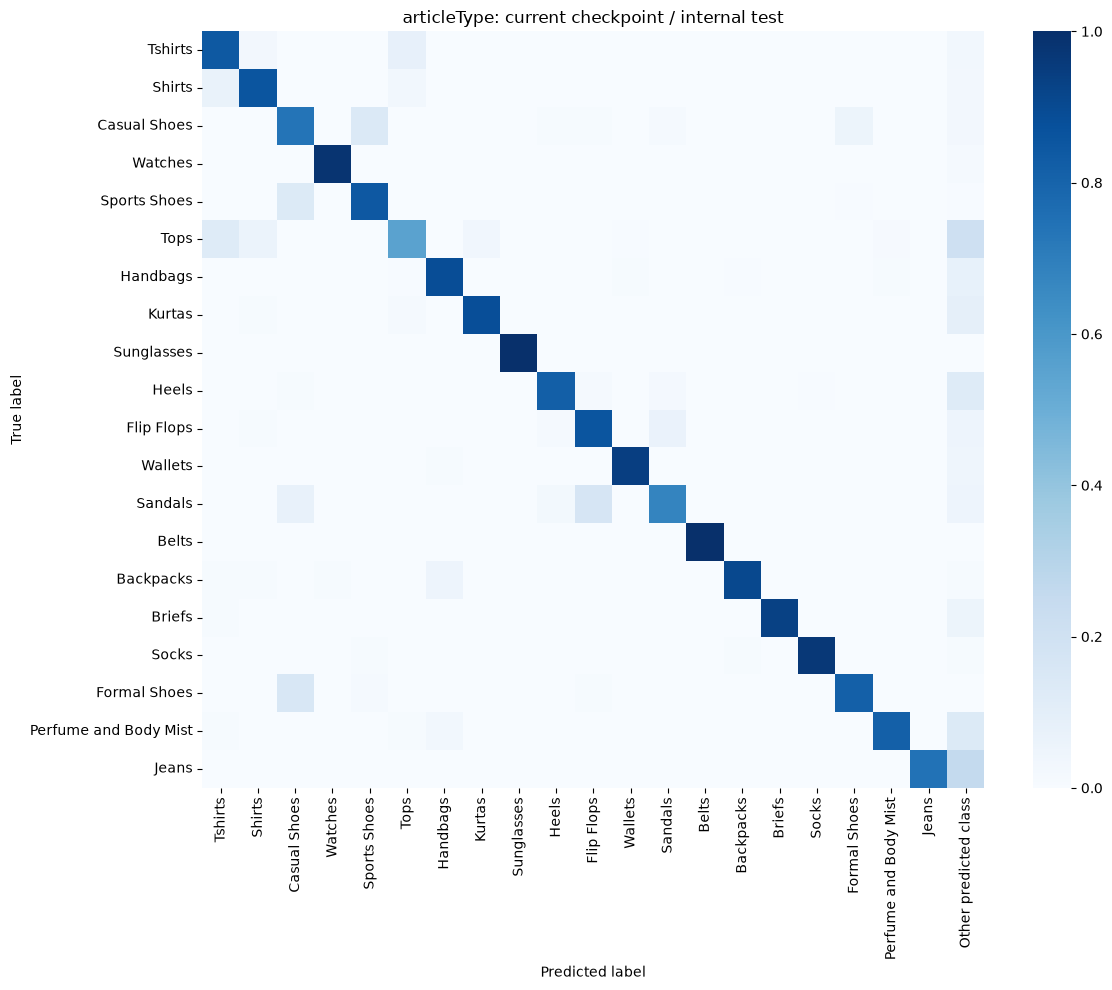

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",0.177500,0.062500,16
"(0.2, 0.3]",0.258236,0.329114,79
"(0.3, 0.4]",0.353669,0.304762,210
"(0.4, 0.5]",0.454232,0.478992,357
"(0.5, 0.6]",0.551256,0.529536,474
"(0.6, 0.7]",0.649609,0.621514,502
"(0.7, 0.8]",0.753606,0.723048,538
"(0.8, 0.9]",0.855336,0.864793,747


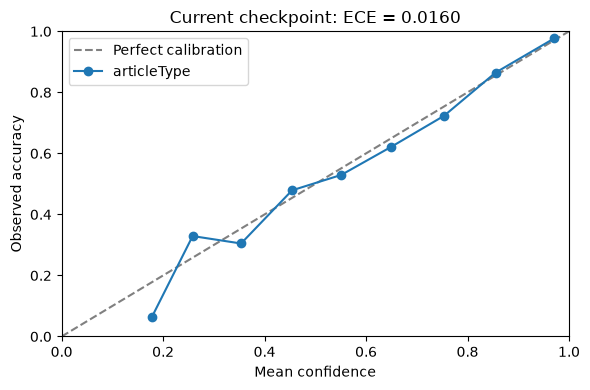

In [ ]:
CURRENT_TARGETS = ['articleType']

from scripts.evaluation import evaluate_saved_checkpoint
from scripts.preprocessing import file_sha256
from sklearn.metrics import confusion_matrix
from IPython.display import display

REPORT_FIGURES = ROOT / 'figures'
REPORT_FIGURES.mkdir(exist_ok=True)
current_results = {}
for target in CURRENT_TARGETS:
    stem = 'article_type' if target == 'articleType' else target
    path = ROOT / 'models' / f'{stem}_model.pt'
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    frame = task_frame(target, 'test')
    result = evaluate_saved_checkpoint(path, frame, device='cpu')
    current_results[target] = result
    print(target, '|', checkpoint['model_type'], '| SHA-256:', file_sha256(path))
    print('Test images:', len(frame), '| saved temperature:', checkpoint.get('temperature', 1.0))
    saved = checkpoint['test_metrics']
    comparison = pd.DataFrame({'checkpoint': saved, 'fresh_evaluation': result['metrics']})
    display(comparison)
    for metric, value in result['metrics'].items():
        np.testing.assert_allclose(value, saved[metric], atol=2e-5, rtol=0)
    supported = np.unique(result['truth'])
    print(classification_report(result['truth'], result['predictions'], labels=supported,
          target_names=[result['labels'][i] for i in supported], zero_division=0))
    np.savez_compressed(REPORT_FIGURES / f'{stem}_evaluation.npz',
        ids=frame.id.astype(str).to_numpy(dtype=str), labels=np.asarray(result['labels']),
        truth=result['truth'], probabilities=result['probabilities'], checkpoint_sha256=file_sha256(path))
    pd.Series(result['metrics']).to_csv(REPORT_FIGURES / f'{stem}_metrics.csv')
    print('Initial validation comparison (historical baseline, not current test scores):')
    display(pd.read_csv(ROOT / 'models' / f'{stem}_comparison.csv'))

for target, result in current_results.items():
    labels = result['labels']
    matrix = confusion_matrix(result['truth'], result['predictions'], labels=np.arange(len(labels)))
    stem = 'article_type' if target == 'articleType' else target
    if target == 'articleType':
        shown = task_frame(target, 'train')[target].value_counts().head(20).index.tolist()
        indices = [labels.index(label) for label in shown]
        other = [i for i in range(len(labels)) if i not in indices]
        counts = np.column_stack([matrix[indices][:, indices], matrix[indices][:, other].sum(1)])
        normalized = counts / counts.sum(1, keepdims=True)
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(normalized, xticklabels=shown + ['Other predicted class'], yticklabels=shown,
                    cmap='Blues', vmin=0, vmax=1, ax=ax)
        ax.set(xlabel='Predicted label', ylabel='True label')
    else:
        fig, ax = plt.subplots(figsize=(8, 7))
        ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'],
            labels=np.arange(len(labels)), display_labels=labels, normalize='true',
            values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{target}: current checkpoint / internal test')
    fig.tight_layout()
    fig.savefig(REPORT_FIGURES / f'{stem}_confusion.png', dpi=220, bbox_inches='tight')
    plt.show()
    reliability = calibration_table(result['truth'], result['probabilities'])
    display(reliability)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
    ax.plot(reliability.mean_confidence, reliability.accuracy, 'o-', label=target)
    ax.set(xlabel='Mean confidence', ylabel='Observed accuracy', xlim=(0, 1), ylim=(0, 1),
           title=f'Current checkpoint: ECE = {result["metrics"]["ece"]:.4f}')
    ax.legend()
    fig.tight_layout()
    fig.savefig(REPORT_FIGURES / f'{stem}_calibration.png', dpi=220, bbox_inches='tight')
    plt.show()